In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Mounted at /content/drive
Preprocess time: 15.35s
Peak RAM: 0.71 GB
Training time: 12.9s
Peak RAM: 0.99 GB

Classification Report on Unseen Test Data:
              precision    recall  f1-score   support

      Normal       0.90      0.85      0.87     11855
 Pre-Failure       0.57      0.66      0.61      3474

    accuracy                           0.81     15329
   macro avg       0.73      0.76      0.74     15329
weighted avg       0.82      0.81      0.82     15329

ROC-AUC: 0.8725
PR-AUC:  0.7210


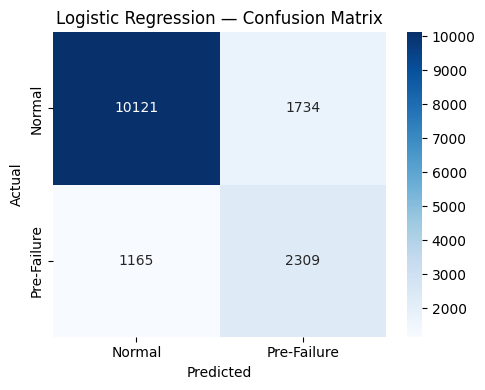

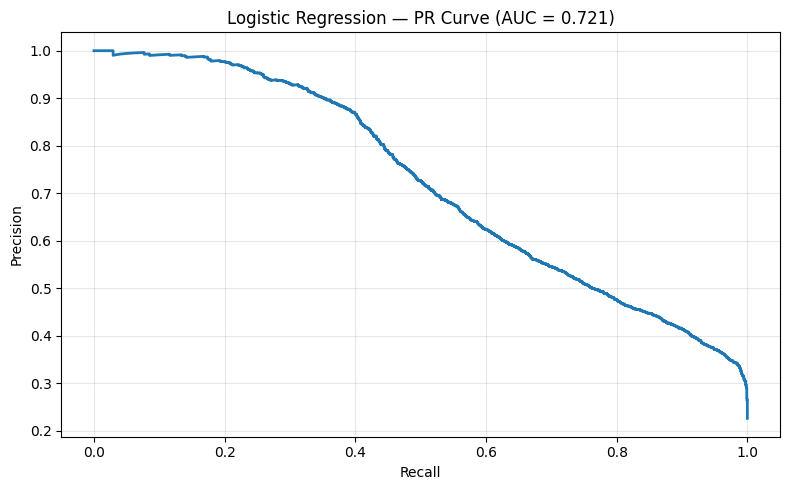

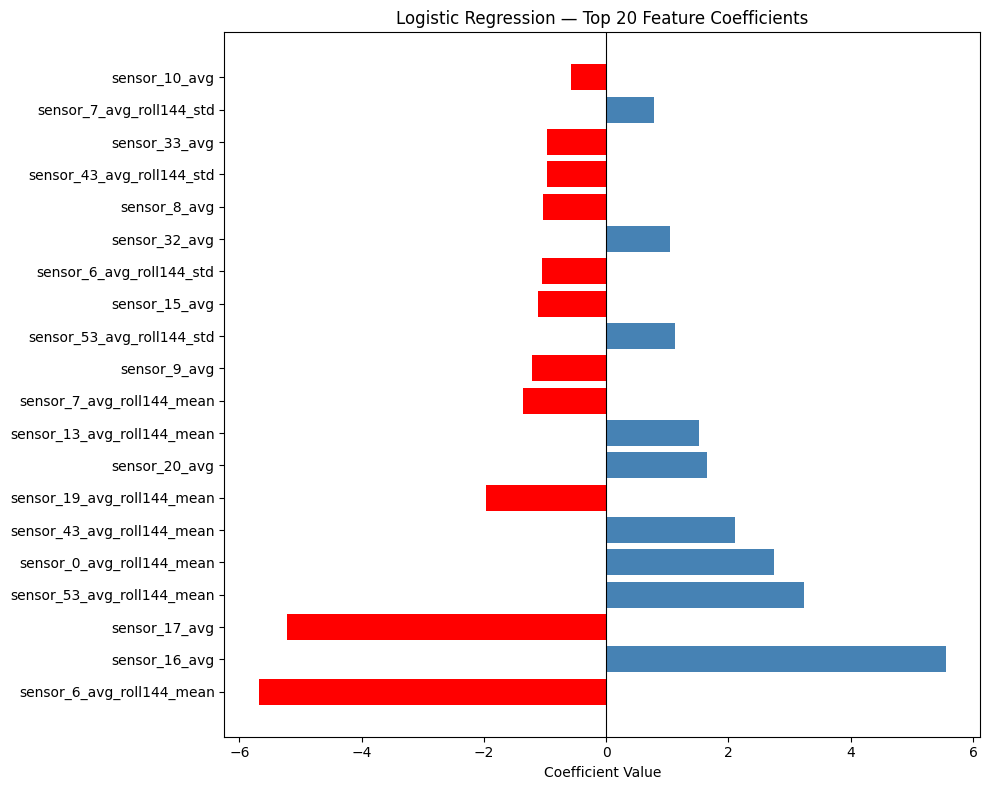


Summary — Logistic Regression
Preprocess time:  15.35s
Training time:    12.9s
Total time:       31.0s
Peak RAM: 0.99 GB


In [ ]:
import pandas as pd
import numpy as np
import time
import resource
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, recall_score,
                             roc_auc_score, precision_recall_curve, auc,
                             average_precision_score)
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Final_Year_Project/'

def get_peak_ram_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

total_start = time.time()
preprocess_start = time.time()

FILES = [
    ('WindFarmA', 0),
    ('WindFarmA', 3),
    ('WindFarmA', 10),
    ('WindFarmA', 13),
    ('WindFarmA', 14),
    ('WindFarmA', 17)
]

rolling_cols = [
    'sensor_5_avg',
    'sensor_31_avg',
    'sensor_0_avg',
    'sensor_43_avg',
    'sensor_53_avg',
    'sensor_19_avg',
    'sensor_6_avg',
    'sensor_7_avg',
    'sensor_41_avg',
    'sensor_13_avg',
    'sensor_14_avg',
]
rolling_windows = [6, 36, 144]

drop_cols = [
    'time_stamp',
    'asset_id',
    'id',
    'train_test',
    'status_type_id',
    'power_29_avg', 'power_29_max', 'power_29_min', 'power_29_std',
    'power_30_avg', 'power_30_max', 'power_30_min', 'power_30_std',
    'wind_speed_3_avg', 'wind_speed_3_max', 'wind_speed_3_min', 'wind_speed_3_std',
    'wind_speed_4_avg',
    'reactive_power_27_avg', 'reactive_power_27_max', 'reactive_power_27_min', 'reactive_power_27_std',
    'reactive_power_28_avg', 'reactive_power_28_max', 'reactive_power_28_min', 'reactive_power_28_std',
    'sensor_35_avg', 'sensor_36_avg', 'sensor_37_avg',
]

# sensors that would leak failure info
dropped_sensors = [
    'sensor_35', 'sensor_36', 'sensor_37',
    'sensor_38', 'sensor_39', 'sensor_40',
    'sensor_18', 'sensor_52',
    'sensor_23', 'sensor_25',
    'sensor_34',
    'sensor_44', 'sensor_48', 'sensor_50',
]

RANDOM_SEED = 42
max_normal= 12_000
all_train, all_test = [], []

for farm, file_num in FILES:
    path = f'{base_path}{farm}/{file_num}.csv'
    df = pd.read_csv(path, sep=';')
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    df = df.sort_values('time_stamp').reset_index(drop=True)

    # remove fault rows, keep normal + pre-failure only
    df = df[df['status_type_id'] != 3].copy()
    df['target'] = (df['status_type_id'] == 4).astype(int)

    for col in rolling_cols:
        if col in df.columns:
            for w in rolling_windows :
                df[f'{col}_roll{w}_mean'] = df[col].rolling(w, min_periods=1).mean()
                df[f'{col}_roll{w}_std'] = df[col].rolling(w, min_periods=1).std().fillna(0)

    df = df.dropna().reset_index(drop=True)

    leaky_cols = [col for col in df.columns if any(col.startswith(root + '_') or col == root for root in dropped_sensors)]
    cols_to_drop = drop_cols + leaky_cols

    train = df[df['train_test'] == 'train'].drop(columns=cols_to_drop, errors='ignore')
    test = df[df['train_test'] == 'prediction'].drop(columns=cols_to_drop, errors='ignore')

    minority = train[train['target'] == 1]
    majority = train[train['target'] == 0]
    n_keep = min(max_normal, len(majority))
    majority_down = majority.sample(n=n_keep, random_state=RANDOM_SEED)
    train = pd.concat([majority_down, minority]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    all_train.append(train)
    all_test.append(test)

train_data = pd.concat(all_train, ignore_index=True)
test_data = pd.concat(all_test, ignore_index=True)

preprocess_time = time.time() - preprocess_start
print(f"Preprocess time: {preprocess_time:.2f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")

X_train, y_train = train_data.drop(columns=['target']), train_data['target']
X_test, y_test = test_data.drop(columns=['target']), test_data['target']

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
start_time = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.1f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")

y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.50).astype(int)

print("\nClassification Report on Unseen Test Data:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pre-Failure']))

roc = roc_auc_score(y_test, y_prob)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
pr = auc(rec_vals, prec_vals)

print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr:.4f}")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pre-Failure'],
            yticklabels=['Normal', 'Pre-Failure'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_vals, prec_vals, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Logistic Regression — PR Curve (AUC = {pr:.3f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

feature_names = X_train.columns.tolist()
coefficients = model.coef_[0]
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).reindex(pd.Series(coefficients).abs().sort_values(ascending=False).index)

top20_coef = coef_df.head(20)

plt.figure(figsize=(10, 8))
colours = ['red' if c < 0 else 'steelblue' for c in top20_coef['coefficient']]
plt.barh(top20_coef['feature'], top20_coef['coefficient'], color=colours)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Top 20 Feature Coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

total_time = time.time() - total_start
print(f"\n{'='*50}")
print(f"SUMMARY — Logistic Regression")
print(f"{'='*50}")
print(f"Preprocess time:  {preprocess_time:.2f}s")
print(f"Training time:    {train_time:.1f}s")
print(f"Total time:       {total_time:.1f}s")
print(f"Peak RAM: {get_peak_ram_gb():.2f} GB")
print(f"{'='*50}")

lr_rec_vals = rec_vals
lr_prec_vals = prec_vals
lr_roc = roc
lr_pr = pr

np.save('/content/drive/MyDrive/Final_Year_Project/Results/lr_y_prob.npy', y_prob)
np.save('/content/drive/MyDrive/Final_Year_Project/Results/lr_y_true.npy', y_test.values)

In [ ]:
# Train vs Test Check
y_train_pred = model.predict(X_train_scaled)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)
print(f"Train F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

Train F1: 0.6921
Test F1:  0.6143
Gap:      0.0778
